### Imports

In [1]:
import os
import sys
import random

In [2]:
import time
import json

In [3]:
import numpy as np

In [4]:
from collections import Counter

In [5]:
import torch
from torch import nn
from torch.nn import functional

In [6]:
from torch.utils.data import Dataset

In [7]:
# import torchvision
import torchvision.transforms as transforms

In [8]:
# Weizmann dataset
from src.load_weizmann import download_weizmann_masks
from src.load_weizmann import PERSONS, ACTIONS, DESCRIPTIONS

In [9]:
# train and validation loops
from src.loops import train_loop, val_loop

In [10]:
# model
from src.network import ConvRecClassifier

In [11]:
from tqdm import tqdm
from datetime import datetime

In [12]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from mpl_toolkits.axes_grid1 import make_axes_locatable

plt.style.use('dark_background')
%matplotlib inline
# %config InlineBackend.figure_format = 'retina'

# Notebook "Weizmann Dataset Recognition" settings

In [13]:
# list of all saved models
dir_models = 'results'

filepathes = []

for file in os.listdir(dir_models):      
    filename = os.fsdecode(file)
    if not filename.endswith(".pth"):
        filepathes.append(filename)

print(*sorted(filepathes), sep='\n')

.DS_Store
exp_09-05-2025_19-23


In [14]:
RESULTS_FOLDER = f'{dir_models}/exp_09-05-2025_19-23'  # SELECTING AN EXPERIMENT
RESULTS_FOLDER

'results/exp_09-05-2025_19-23'

In [15]:
# OR read conditions from file:
with open(f'{RESULTS_FOLDER}/conditions.json') as json_file:
    VARIABLES = json.load(json_file)

VARIABLES

{'data_path': 'data/',
 'results_path': 'results/exp_09-05-2025_19-23',
 'sequence_len': 3,
 'skip_between_frames': 2,
 'augmentation_flip': True,
 'center_silhouettes': True,
 'exclude_cutted_silhouettes': True,
 'weighted_classes': True,
 'feature_dim': 16,
 'hidden_dim': 16,
 'DEVICE': 'cpu',
 'train_batch_size': 10,
 'val_batch_size': 20,
 'adam_lr': 0.001,
 'number_of_epochs': 10}

# 1. Dataset preparation

## Load data

> The extracted masks obtained by background subtraction: the file (Matlab 7 format, ~1700KB) contains both the original masks as well as the aligned ones (that were the actual inputs to our algorithm).

<span style="color:red">**Comment:**</span> All masks are of the shape $64 \times 64$.

In [16]:
WEIZMANN_DIR = VARIABLES['data_path']

#### Load masks

In [17]:
# uncomment to download masks:
download_weizmann_masks(dest=WEIZMANN_DIR)

Saving masks for `bend` as .npy to `data/bend_masks`... Done!
Saving masks for `jack` as .npy to `data/jack_masks`... Done!
Saving masks for `jump` as .npy to `data/jump_masks`... Done!
Saving masks for `pjump` as .npy to `data/pjump_masks`... Done!
Saving masks for `run` as .npy to `data/run_masks`... Done!
Saving masks for `side` as .npy to `data/side_masks`... Done!
Saving masks for `skip` as .npy to `data/skip_masks`... Done!
Saving masks for `walk` as .npy to `data/walk_masks`... Done!
Saving masks for `wave1` as .npy to `data/wave1_masks`... Done!
Saving masks for `wave2` as .npy to `data/wave2_masks`... Done!


#### Actions labels

In [18]:
NUM_ACTIONS = len(ACTIONS)

In [19]:
with open(f'{RESULTS_FOLDER}/id2action.json') as json_file:
    ID_TO_ACTION = json.load(json_file)

ID_TO_ACTION = {int(idx): act for idx, act in ID_TO_ACTION.items()}

ACTION_TO_ID = {act: idx for idx, act in ID_TO_ACTION.items()}
ACTION_TO_ID

{'bend': 0,
 'jack': 1,
 'jump': 2,
 'pjump': 3,
 'run': 4,
 'side': 5,
 'skip': 6,
 'walk': 7,
 'wave1': 8,
 'wave2': 9}

## 1.1. Train and Test data 


In [20]:
# list of train files
all_train_files = []

with open(f'{RESULTS_FOLDER}/train_files.txt') as file:
    all_train_files = [line.rstrip('\n') for line in file]

In [21]:
# list of test files
all_test_files = []

with open(f'{RESULTS_FOLDER}/test_files.txt') as file:
    all_test_files = [line.rstrip('\n') for line in file]

In [22]:
print(f'Train files: {len(all_train_files)}')
print(f'Test  files: {len(all_test_files)}')

Train files: 60
Test  files: 30


## 1.2. Data sequencing 

Each video will be divided into numbers of sub-sequences by sequentially extracting `SEQ_LEN` frames for each sub-sequence with a frame interval of `SKIP`.

In [23]:
SEQ_LEN = VARIABLES['sequence_len']
SKIP = VARIABLES['skip_between_frames']  # it is a skip between timesteps in sequences

## 1.3. Dataset construction

#### <span style="color:red">Data augmentation</span>

The data augmentation (horizontally flip) can be performed for videos! It will make dataset of sub-sequences as twice as large!

In [24]:
INIT_MASK_SIZE = 64  # each loaded mask is of the shape 64x64

### 1.3.1. Centering of silhouettes

In [25]:
# we can center each silhouette before forming a subsequence!
CENTERING = VARIABLES['center_silhouettes']

# for silhouette detection (needed if CENTERING == True)
BRIGHTNESS_LIM = 0.05  # value from 0 to 1 to build strickt boundaries of a silhouette
# Comment: in fact it is a hyperparameter
CENTERED_MASK_SIZE = INIT_MASK_SIZE

# We add 0's padding to a silhouette rectangle to make a square of the following size!

### 1.3.2. Exclude cutted (incomplete) silhouettes

In [26]:
EXCLUDE_CUTTED = VARIABLES['exclude_cutted_silhouettes']
# Comment: Some frames are cutted because for some actions a person appears within 
#          a frame and goes to the opposite boundary! 

# Criterias to exclude a frame because of a part of a silhouette is out of frame:
# 1. one of boundaries of a silhouette bounding box coincides with a boundary of a frame;
# 2. if 1^st criteria satisfied and a width of a silhouette bounding box is less than some value
CUTTED_MIN_WIDTH = 15 
# Comment: in fact it is a hyperparameter...

### 1.3.3. Dataset class

In [27]:
import src.dataset
from src.dataset import WeizmannSeqs

# transfer all constant to module
src.dataset.INIT_MASK_SIZE = INIT_MASK_SIZE
src.dataset.CENTERED_MASK_SIZE = CENTERED_MASK_SIZE

src.dataset.ACTION_TO_ID = ACTION_TO_ID

src.dataset.BRIGHTNESS_LIM = BRIGHTNESS_LIM
src.dataset.CUTTED_MIN_WIDTH = CUTTED_MIN_WIDTH

### 1.3.4. Train and Test datasets of sub-sequences

In [28]:
# if True uses a horisotal flip to make dataset twice as large
AUGMENTATION_FLIP = VARIABLES['augmentation_flip']

In [29]:
train_seqs_ds = WeizmannSeqs(
    all_train_files,
    seq_len=SEQ_LEN,
    skip=SKIP,
    augmentation_horizontally_flip=AUGMENTATION_FLIP,  # no horizontal flip!
    exclude_cutted=EXCLUDE_CUTTED,
    centering=CENTERING,
)  # item: (sequence, label)

test_seqs_ds = WeizmannSeqs(
    all_test_files,
    seq_len=SEQ_LEN,
    skip=SKIP,
    augmentation_horizontally_flip=AUGMENTATION_FLIP,  # no horizontal flip!
    exclude_cutted=EXCLUDE_CUTTED,
    centering=CENTERING,
)  # item: (sequence, label)

In [30]:
print(f'Train dataset of sequences: {len(train_seqs_ds)}')
print(f'Test  dataset of sequences: {len(test_seqs_ds)}')

Train dataset of sequences: 6896
Test  dataset of sequences: 3064


# 3. Neural Network

## 3.1. Network architecture

In [31]:
FEATURE_DIM = VARIABLES['feature_dim']
HIDDEN_DIM = VARIABLES['hidden_dim']  # hyperparameters

In [32]:
def get_net():
    return ConvRecClassifier(
        feature_dim=FEATURE_DIM,
        hidden_dim=HIDDEN_DIM,
        num_classes=NUM_ACTIONS
    )

## 3.3. Necessary things for future training

### 3.3.1. Loss function and optimizer

In [33]:
loss_func_clf = nn.CrossEntropyLoss()
loss_func_name = 'CE loss'

In [34]:
LR = VARIABLES['adam_lr']

In [35]:
def get_adam_optimizer(net):
    return torch.optim.Adam(
        params=net.parameters(),  # NETWORK PARAMETERS!
        lr=LR
    )

### 3.3.2. Data loaders

In [36]:
train_bs = VARIABLES['train_batch_size']  # a batch size for training set
val_bs = VARIABLES['val_batch_size']

In [37]:
train_dataloader = torch.utils.data.DataLoader(
    train_seqs_ds,
    batch_size=train_bs,
    shuffle=True,
    drop_last=False,
)

test_dataloader = torch.utils.data.DataLoader(
    test_seqs_ds,
    batch_size=val_bs,
    shuffle=True,
    drop_last=False,
)

# 4. Results Loading

## 4.1. Model weights

In [38]:
load_model_filepath = f'{RESULTS_FOLDER}/recurrent_net.pth'

loaded_nn = get_net()
loaded_nn.load_state_dict(torch.load(load_model_filepath))

/var/folders/mt/0w6nmsr119bb2g4h4xrv9p6m0000gn/T/ipykernel_5439/3409713306.py:4: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  loaded_nn.load_state_dict(torch.load(load_mode

<All keys matched successfully>

### 4.1.1. Metrics on test dataset

In [39]:
test_losses_0, _, test_accuracy_0 = val_loop(
    loaded_nn,
    test_dataloader,
    loss_func_clf,
    show_process=True,
)  # evaluate the model

print(
    'Results for the loaded net on TEST set:\n' + 
    f'\t{loss_func_name} : {np.mean(test_losses_0):.6f}\n' +
    f'\tAccuracy : {(test_accuracy_0*100):>0.1f} %'
)

validation: 100%|████████████████████████████| 154/154 [00:00<00:00, 209.97it/s]

Results for the loaded net on TEST set:
	CE loss : 0.638759
	Accuracy : 85.4 %


## 4.2. Learning curves

In [40]:
losses_data = np.genfromtxt(
    f'{RESULTS_FOLDER}/training_curves.csv',
    delimiter=','
)

In [41]:
n_epochs = VARIABLES['number_of_epochs']
(train_epochs_losses, val_epochs_losses, train_epochs_acc, val_epochs_acc) = losses_data[1:, :].T

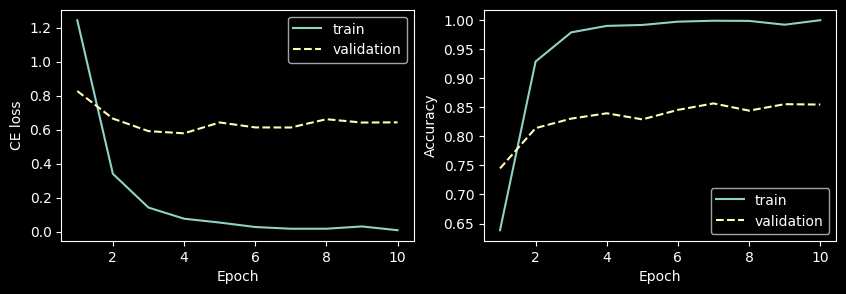

In [42]:
# learning curve
fig, axs = plt.subplots(1, 2, figsize=(10, 3))

axs[0].plot(range(1, n_epochs + 1), np.array(train_epochs_losses), label='train')
axs[0].plot(range(1, n_epochs + 1), np.array(val_epochs_losses), linestyle='dashed', label='validation')

axs[1].plot(range(1, n_epochs + 1), train_epochs_acc, label='train')
axs[1].plot(range(1, n_epochs + 1), val_epochs_acc, linestyle='dashed', label='validation')

axs[0].set_ylabel(loss_func_name)
axs[0].set_xlabel('Epoch')
axs[0].legend()

axs[1].set_ylabel('Accuracy')
axs[1].set_xlabel('Epoch')
axs[1].legend()

plt.show()

## 4.3. Predicting complete video class

In [65]:
def predict_video(net, masks_filepath, flip=True, show_process=True):

    action_name = masks_filepath.split('/')[-2].split('_')[0]  # depends on a data directory!
    label = ACTION_TO_ID[action_name]  # label for the sequence
    
    file_seqs_ds = WeizmannSeqs(
        [masks_filepath],
        seq_len=SEQ_LEN,
        skip=SKIP,
        augmentation_horizontally_flip=flip,  # no horizontal flip!
        exclude_cutted=EXCLUDE_CUTTED,
        centering=CENTERING,
    )
    dataloader = torch.utils.data.DataLoader(
        file_seqs_ds,
        batch_size=1,
        shuffle=False,
        drop_last=False,
    )
    
    seqs_pred_labels = []

    if flip:# sum of all detector images for each flipped squence of the video
        flipped_seqs_pred_labels = []

    ind_this = 0
    for seq_wavefronts, seq_label in tqdm(dataloader, disable=not show_process):
        
        net.eval()  # pedict sequence:
        with torch.no_grad():
            seq_probas = net(seq_wavefronts.float())
    
            pred_label_this = seq_probas.argmax().item()  # predicted label
            
            if flip:
                if ind_this % 2 == 0:  # not flipped sequence
                    seqs_pred_labels.append(pred_label_this)
                else:  # flipped sequence
                    flipped_seqs_pred_labels.append(pred_label_this)
            else:
                seqs_pred_labels.append(pred_label_this)

        ind_this +=1

    if flip:
        return seqs_pred_labels, flipped_seqs_pred_labels, label
    else:
        return seqs_pred_labels, label

### 4.3.1. Example of predicting a selected video

In [66]:
test_filepath = all_test_files[22]  # select any filepath from test set
test_filename = test_filepath.split('/')[-1]

use_flipped_seqs = True  # using horizontal flip to predict file or not

print(test_filename)

ira_walk.npy


In [67]:
# predicting a file by all subsequences
labels_by_seqs, labels_by_flipped_seqs, label_0 = predict_video(
    loaded_nn, test_filepath, flip=True
)

100%|███████████████████████████████████████| 162/162 [00:00<00:00, 1759.23it/s]


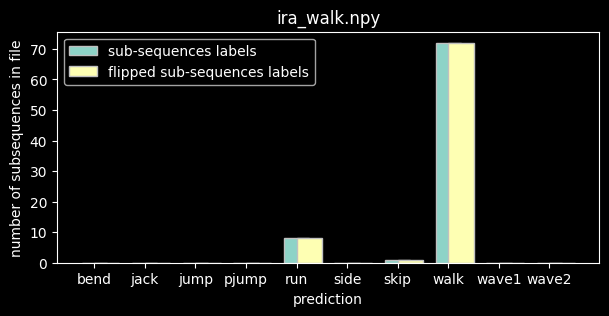

In [68]:
fig, ax0 = plt.subplots(1, 1, figsize=(7, 3))
bars_width = 0.5
bars_shift = 0.25

ax0.hist(
    labels_by_seqs, bins=list(range(NUM_ACTIONS + 1)),
    align='left', rwidth=bars_width, label='sub-sequences labels',
    edgecolor='silver'
)

ax0.hist(
    np.array(labels_by_flipped_seqs) + bars_shift, 
    bins=np.arange(NUM_ACTIONS + 1) + bars_shift,
    align='left', rwidth=bars_width, label='flipped sub-sequences labels',
    edgecolor='silver'
)

# axes settings
ax0.set_title(test_filepath.split('/')[-1])

ax0.set_xticks(range(NUM_ACTIONS))
ax0.set_xticklabels([ID_TO_ACTION[ind] for ind in range(NUM_ACTIONS)])

ax0.set_ylabel('number of subsequences in file')
ax0.set_xlabel('prediction')

# ax0.set_ylim([0, 1000])

ax0.legend()
plt.show()

### 4.3.2. Predicting all test videos

In [69]:
NUM_TEST_FILES = len(all_test_files)

In [70]:
# confusion matrix
# prediction by subsequences labels
confusion_matrix_top_seqs = torch.zeros(size=(len(all_test_files), NUM_ACTIONS), dtype=torch.int32)

In [80]:
true_predictions = 0
false_predictions = 0

top_length = 1  # check top 3 predictions
in_top = 0

for ind_file, filepath in enumerate(tqdm(all_test_files)):
    pred_labels_1, pred_labels_2, true_label = predict_video(
        loaded_nn, filepath, flip=True, show_process=False
    )

    # ind_file must be connected with label!
    # all_test_files is sorted by actions!
    
    counter_preds = Counter(pred_labels_1 + pred_labels_2)
    # update confusion matrix
    confusion_matrix_top_seqs[ind_file, :] = torch.tensor([counter_preds[label] for label in range(NUM_ACTIONS)])
    
    # is the true prediction in top N?
    top_preds = counter_preds.most_common(top_length)
    for pred, _ in top_preds:
        if pred == true_label:
            in_top += 1
            break
    
    if top_preds[0][0] == true_label:
        true_predictions += 1
    else:
        false_predictions += 1

print(f'Files prediction accuracy: {true_predictions / (true_predictions + false_predictions) * 100 :.2f}%')
print(f'True label in top-{top_length} predictions for {in_top} out of {len(all_test_files)} test files')

100%|███████████████████████████████████████████| 30/30 [00:01<00:00, 24.49it/s]

Files prediction accuracy: 96.67%
True label in top-1 predictions for 29 out of 30 test files


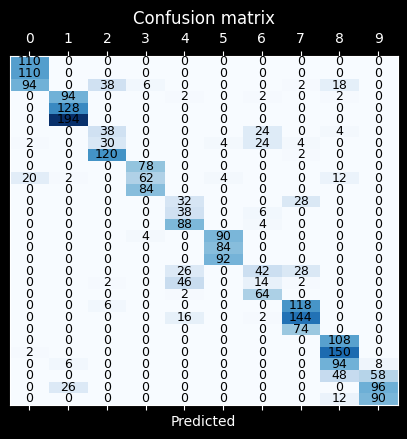

In [83]:
fig, ax0 = plt.subplots(1, 1, figsize=(5, 5))

# CONFUSION MATRIX
ax0.set_title('Confusion matrix')
ax0.matshow(confusion_matrix_top_seqs, cmap='Blues')

for i in range(NUM_ACTIONS):
    for j in range(NUM_TEST_FILES):
        val = confusion_matrix_top_seqs[j, i].item()
        ax0.text(
            i, j, str(val),
            va='center', ha='center', 
            c='k', fontsize=9
        )

# ax0.set_ylabel('Target')
ax0.set_xlabel('Predicted')

ax0.set_xticks(range(NUM_ACTIONS))
ax0.set_yticks([])  # (range(NUM_TEST_FILES))
ax0.set_aspect(0.3)

plt.show()

In [84]:
ID_TO_ACTION

{0: 'bend',
 1: 'jack',
 2: 'jump',
 3: 'pjump',
 4: 'run',
 5: 'side',
 6: 'skip',
 7: 'walk',
 8: 'wave1',
 9: 'wave2'}